In [ ]:
%%capture
%pip install -q \
  "langgraph" \
  "google-generativeai" \
  "pandas" \
  "langchain" \
  "langchain-openai" \
  "langchain-chroma>=0.1.2" \
  "opentelemetry-api>=1.36.0,<1.39.0" \
  "opentelemetry-sdk>=1.36.0,<1.39.0"


!pip install -U langchain langchain-core langchain-community langsmith twilio sendgrid apscheduler supabase

In [ ]:
from __future__ import annotations
import logging
import operator
import time
from enum import Enum
from typing import Annotated, Any, Optional, TypedDict, Dict, List
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, START, StateGraph
from langgraph.types import Command, interrupt
from langchain_openai import OpenAI
from langchain_openai import ChatOpenAI
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain.agents import create_agent
import chromadb
from uuid import uuid4
from datetime import datetime, timedelta

import os
from datetime import datetime, timedelta
from typing import Optional

from langchain_core.tools import tool
from twilio.rest import Client as TwilioClient
import sendgrid
from sendgrid.helpers.mail import Mail
from apscheduler.schedulers.background import BackgroundScheduler
from apscheduler.jobstores.sqlalchemy import SQLAlchemyJobStore
import httpx
import sqlite3
from langgraph.constants import Send
from langgraph.types import Command

from supabase import create_client, Client
import re
import json

/tmp/ipykernel_1123/679806135.py:31: LangGraphDeprecatedSinceV10: Importing Send from langgraph.constants is deprecated. Please use 'from langgraph.types import Send' instead. Deprecated in LangGraph V1.0 to be removed in V2.0.
  from langgraph.constants import Send


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
key = 'OPENAI API KEY'
key2 = 'CHROMA DB KEY'

os.environ["TWILIO_ACCOUNT_SID"] = 'TWILIO ACCOUNT SID'
os.environ["TWILIO_AUTH_TOKEN"] = 'TWILIO AUTH TOKEN'
os.environ["TWILIO_FROM_NUMBER"] = 'TWILIO FROM NUMBER'
physician_number = 'PHYSICIAN NUMBER'
CARE_TEAM_NUMBER = 'CARETEAM NUMBER'


# SmarCloud100

SUPABASE_URL = "SUPABASE URL"
SUPABASE_KEY = "SUPABASE KEY"
SUPABASE_DB_URL = "SUPABASE DB URL"
SUPABASE_DB_REST_URL = "SUPABASE DB REST URL"



In [ ]:
embeddings = OpenAIEmbeddings(model="text-embedding-ada-002", api_key=key)

In [ ]:
client = chromadb.CloudClient(
    api_key=key2,
    tenant="dea0acdb-6e27-490d-acdc-9f657d66496e",
    database="AI_Followup_Assistant",
)

vector_store = Chroma(
  client = client,
  collection_name="patient_data",
  embedding_function=embeddings
)

In [ ]:
supabase : supa_client = create_client(SUPABASE_URL,SUPABASE_KEY)

In [ ]:
import pandas as pd

patient_data_path = '/content/sample_patient_data.csv'
patient_df = pd.read_csv(patient_data_path)
display(patient_df.head())


def _parse_follow_up_days(raw: str) -> list[int]:
    try:
        days = [int(d.strip()) for d in str(raw).split("|") if d.strip()]
        return sorted(set(days)) if days else [1, 3, 7]
    except Exception:
        return [1, 3, 7]


def _parse_comorbidities(raw: str) -> list[str]:
    parts = [p.strip().lower() for p in str(raw).split(",") if p.strip()]
    return [p for p in parts if p != "none"]


def _clean_contact(raw) -> str:
    return str(int(float(str(raw))))


def _validate_row(row: pd.Series) -> list[str]:
    errors = []
    required = [
        "patient_id", "patient_name", "diagnosis", "discharge_date",
        "contact", "risk_level", "follow_up_days", "care_plan",
    ]
    for col in required:
        val = row.get(col, None)
        if val is None or (isinstance(val, float) and pd.isna(val)) or str(val).strip() == "":
            errors.append(f"missing '{col}'")

    risk = str(row.get("risk_level", "")).strip().lower()
    if risk not in {"low", "medium", "high"}:
        errors.append(f"invalid risk_level '{risk}'")

    return errors

def _patient_document(row: pd.Series) -> str:
  """
  Rich free-text string that gets embedded.
  Designed so queries like "diabetic post-surgery dizziness" surface
  the right patients via cosine similarity.
  """
  comorbidities = ", ".join(_parse_comorbidities(row["comorbidities"])) or "none"
  return (
      f"Patient {row['patient_name']}, age {row['age']}, "
      f"diagnosed with {row['diagnosis']}. "
      f"Comorbidities: {comorbidities}. "
      f"Last reported symptoms: {row['last_reported_symptoms']}. "
      f"Care plan: {row['care_plan']}. "
      f"Risk level: {row['risk_level']}. "
      f"Medication adherence: {row['medication_adherence_pct']}%. "
      f"Missed appointments: {row['missed_appointments']}. "
      f"Prior readmissions: {row['prior_readmissions']}."
  )


def _patient_metadata(row: pd.Series) -> dict:
    """
    Structured fields stored alongside the vector.
    Supports metadata-filtered queries:
        collection.query(..., where={"risk_level": "high"})
    """
    return {
        "patient_id":str(row["patient_id"]),
        "patient_name":str(row["patient_name"]),
        "age": int(row["age"]),
        "diagnosis": str(row["diagnosis"]),
        "discharge_date": str(row["discharge_date"]),
        "contact": _clean_contact(row["contact"]),
        "preferred_channel": str(row["preferred_channel"]),
        "language": str(row["language"]),
        "risk_level": str(row["risk_level"]).lower(),
        "follow_up_days": json.dumps(_parse_follow_up_days(row["follow_up_days"])),
        "symptom_score": int(row["symptom_score"]),
        "medication_adherence_pct": int(row["medication_adherence_pct"]),
        "missed_appointments": int(row["missed_appointments"]),
        "prior_readmissions": int(row["prior_readmissions"]),
        "comorbidities":json.dumps(_parse_comorbidities(row["comorbidities"])),
        "last_reported_symptoms": str(row["last_reported_symptoms"]),
        "care_plan": str(row["care_plan"]),
    }


def _guideline_document(care_plan: str, diagnosis: str) -> str:
    """
    Enriched text for the care_guidelines collection.
    The notebook RAGPipeline queries: "Discharge guidelines for <diagnosis>".
    """
    return f"Diagnosis: {diagnosis}. Care guidelines: {care_plan}"


In [ ]:
import json
from langchain_core.documents import Document

documents = []
ids = []

for _, row in patient_df.iterrows():
    errors = _validate_row(row)

    if errors:
        print(f"Skipping patient {row.get('patient_id')} -> {errors}")
        continue

    page_content = _patient_document(row)
    metadata = _patient_metadata(row)
    doc_id = str(row["patient_id"])

    documents.append(
        Document(
            page_content=page_content,
            metadata=metadata
        )
    )

    ids.append(doc_id)

collection = client.get_or_create_collection("patient_data")
existing_count = collection.count()
MAX_RECORDS = 300
remaining_slots = MAX_RECORDS - existing_count

print(f"Total prepared: {len(documents)} | Existing in DB: {existing_count} | Slots available: {remaining_slots}")

if remaining_slots <= 0:
    print("Quota full. Clear the collection or request a quota increase.")
    print(f"Request increase: https://trychroma.com/request-quota-increase?tenant=dea0acdb-6e27-490d-acdc-9f657d66496e&action=Upsert&quota=NumRecords&current=300&request=500")
else:
    documents_to_insert = documents[:remaining_slots]
    ids_to_insert = ids[:remaining_slots]

    vector_store.add_documents(documents=documents_to_insert, ids=ids_to_insert)

    skipped = len(documents) - len(documents_to_insert)
    print(f"Ingested {len(documents_to_insert)} patient records into ChromaDB.")
    if skipped > 0:
        print(f"Skipped {skipped} records — quota limit reached. Request increase to insert remaining.")
        print(f"Request increase: https://trychroma.com/request-quota-increase?tenant=dea0acdb-6e27-490d-acdc-9f657d66496e&action=Upsert&quota=NumRecords&current=300&request=500")

In [ ]:
results = vector_store.similarity_search(
    query="high risk cardiac patient",
    k=5,
    filter={"risk_level": "high"}
)

results

[Document(id='P0026', metadata={'patient_name': 'Aarav Garcia', 'preferred_channel': 'email', 'last_reported_symptoms': 'mild fatigue', 'prior_readmissions': 1, 'language': 'Hindi', 'discharge_date': '2026-04-04', 'comorbidities': '["hypertension"]', 'patient_id': 'P0026', 'contact': '15550000026', 'age': 69, 'symptom_score': 1, 'care_plan': 'Daily weight checks, low-sodium diet, medication adherence, cardiology follow-up within 7 days.', 'risk_level': 'high', 'follow_up_days': '[1, 2, 3, 5, 7]', 'diagnosis': 'Heart Failure', 'missed_appointments': 3, 'medication_adherence_pct': 64}, page_content='Patient Aarav Garcia, age 69, diagnosed with Heart Failure. Comorbidities: hypertension. Last reported symptoms: mild fatigue. Care plan: Daily weight checks, low-sodium diet, medication adherence, cardiology follow-up within 7 days.. Risk level: high. Medication adherence: 64%. Missed appointments: 3. Prior readmissions: 1.'),
 Document(id='P0033', metadata={'preferred_channel': 'phone', 'pa

In [ ]:
collection = vector_store._collection
print(collection.count())

300


In [ ]:
llm = ChatOpenAI(model="gpt-4o", temperature=0,api_key=key)

In [ ]:
logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s [%(levelname)s] %(name)s — %(message)s",
)


class WorkflowLogger:
    """Central logger for all agent decisions and workflow events."""

    def __init__(self, name: str = "PatientFollowUp") -> None:
        self._log = logging.getLogger(name)

    def info(self, node: str, msg: str, meta: dict = {}) -> None:
        self._log.info("[%s] %s | %s", node, msg, meta)

    def warn(self, node: str, msg: str) -> None:
        self._log.warning("[%s] %s", node, msg)

    def error(self, node: str, msg: str, meta: dict = {}) -> None:
        self._log.error("[%s] ERROR: %s | %s", node, msg, meta)

In [ ]:
class MetricsDashboard:
    """Tracks key workflow metrics for observability (module-level singleton)."""

    _counters: dict[str, int] = {
        "patients_processed": 0,
        "reminders_sent": 0,
        "escalations_triggered": 0,
        "human_approvals_pending": 0,
        "errors_caught": 0,
    }

    @classmethod
    def increment(cls, key: str, value: int = 1) -> None:
        cls._counters[key] = cls._counters.get(key, 0) + value

    @classmethod
    def snapshot(cls) -> dict:
        return dict(cls._counters)

In [ ]:
logger  = WorkflowLogger()
metrics = MetricsDashboard()

In [ ]:
class RiskLevel(str, Enum):
    LOW = "low"
    MEDIUM = "medium"
    HIGH = "high"

class GraphState(TypedDict):
    patient_id: str
    patient_name: str
    diagnosis: str
    discharge_date: str
    contact: str
    risk_level: str
    original_risk_level: str
    follow_up_days: list[int]
    preferences: Optional[dict]
    patient_list: Optional[list[str]]
    escalation_report: Optional[str]

    # outputs
    summary: Optional[str]
    initial_summary: Optional[str]
    care_plan: Optional[str]
    reminders_sent: Annotated[list[str], operator.add]
    escalation_task_id: Optional[str]

    # Control flags
    escalation_required: bool
    human_approved: bool
    route: str

    # Observability
    errors: Annotated[list[str], operator.add]
    metrics_snapshot: Optional[dict]
    discharge_guidelines: Optional[str]

    conversation: Optional[ConversationState]

    # patient feedback / re-triage
    symptom_response: Optional[str]
    symptom_score_updated: Optional[int]
    last_contact_acknowledged: Optional[bool]
    silence_hours: Optional[int]



In [ ]:
class ConversationState(TypedDict):
    """Represents the state of a conversation, typically for storing messages."""
    messages: Annotated[list[Any], operator.add]


In [ ]:
class RAGPipeline:
    def retriever(
        self,
        query: str,
        top_k: int = 3,
    ) -> str:
        """Retrieve relevant patient context from vector store."""
        docs = vector_store.similarity_search(query=query, k=top_k)
        context = "\n\n".join([doc.page_content for doc in docs])
        return context

    def retrieve_and_generate(
        self,
        query: str,
        top_k: int = 3,
    ) -> str:
        """Retrieve context and generate response."""
        docs = vector_store.similarity_search(query=query, k=top_k)
        context = "\n\n".join([doc.page_content for doc in docs])

        prompt = f"""Based on the following context, answer the query concisely.

Context:
{context}

Query: {query}

Answer:"""
        response = llm.invoke(prompt)
        return response.content

In [ ]:
rag_pipeline = RAGPipeline()

In [ ]:
# rag_pipeline.retriever("diabetic post-surgery dizziness") #USE FOR DEBUGGING

In [ ]:
def with_retry(max_attempts: int = 3, delay_seconds: float = 1.0):
    """Decorator: retries the wrapped function on any exception."""
    def decorator(fn):
        def wrapper(*args, **kwargs):
            for attempt in range(1, max_attempts + 1):
                try:
                    return fn(*args, **kwargs)
                except Exception as exc:
                    logger.error(fn.__name__,
                                 f"Attempt {attempt}/{max_attempts} failed: {exc}")
                    if attempt == max_attempts:
                        raise
                    time.sleep(delay_seconds)
        return wrapper
    return decorator


def safe_node(node_fn):
    """
    Decorator: wraps any graph node with standardised error handling.
    Catches all exceptions, logs them, increments error metric,
    and returns a safe partial state with the error recorded.
    """
    def wrapper(state: GraphState) -> dict:
        try:
            return node_fn(state)
        except Exception as exc:
            metrics.increment("errors_caught")
            logger.error(node_fn.__name__, str(exc), {"patient_id": state.get("patient_id")})
            return {"errors": [f"[{node_fn.__name__}] {exc}"]}
    return wrapper

def _format_messages(messages: list[dict]) -> str:
    """Formats conversation history into a readable string for agent prompts."""
    return "\n".join(
        f"{m['role'].upper()}: {m['content']}"
        for m in messages
        if m.get("content")
    )

In [ ]:
CARE_PLAN_GUIDELINES = {
    "diabetes": {
        "diet": [
            "Avoid high sugar foods",
            "Eat balanced meals every 4 hours",
            "Increase fiber intake"
        ],
        "medications": [
            "Take insulin as prescribed",
            "Monitor blood sugar twice daily"
        ],
        "exercise": [
            "30 minutes walking daily"
        ],
        "warning_signs": [
            "Blurred vision",
            "Dizziness",
            "Blood sugar above 250"
        ],
        "follow_up": "Visit endocrinologist within 7 days"
    },

    "hypertension": {
        "diet": [
            "Low sodium diet",
            "Avoid processed foods"
        ],
        "medications": [
            "Take BP medications regularly"
        ],
        "exercise": [
            "Light exercise 20 minutes daily"
        ],
        "warning_signs": [
            "Chest pain",
            "Severe headache",
            "Shortness of breath"
        ],
        "follow_up": "BP check within 5 days"
    },

    "cardiac surgery": {
        "diet": [
            "Heart healthy low-fat diet"
        ],
        "medications": [
            "Continue anticoagulants as prescribed"
        ],
        "exercise": [
            "Avoid heavy lifting for 6 weeks"
        ],
        "warning_signs": [
            "Chest pain",
            "Bleeding",
            "Breathing difficulty"
        ],
        "follow_up": "Cardiology review within 3 days"
    },

    "chronic kidney disease": {
        "diet": [
            "Limit potassium and phosphorus intake",
            "Reduce protein consumption",
            "Restrict fluid intake if advised"
        ],
        "medications": [
            "Take phosphate binders with meals",
            "Monitor diuretics as prescribed"
        ],
        "exercise": [
            "Light walking 15–20 minutes daily",
            "Avoid strenuous activity"
        ],
        "warning_signs": [
            "Swelling in legs or ankles",
            "Decreased urine output",
            "Extreme fatigue or confusion"
        ],
        "follow_up": "Nephrology review within 7 days"
    },

    "copd": {
        "diet": [
            "Eat small, frequent meals to avoid breathlessness",
            "High calorie, high protein diet if underweight"
        ],
        "medications": [
            "Use bronchodilator inhaler as prescribed",
            "Take corticosteroids only as directed"
        ],
        "exercise": [
            "Breathing exercises twice daily",
            "Short walks — stop if breathless"
        ],
        "warning_signs": [
            "Increased breathlessness at rest",
            "Coughing up blood",
            "Bluish lips or fingertips"
        ],
        "follow_up": "Pulmonologist visit within 7 days"
    },

    "stroke": {
        "diet": [
            "Soft or pureed diet if swallowing is impaired",
            "Low sodium, heart-healthy meals"
        ],
        "medications": [
            "Take antiplatelets or anticoagulants as prescribed",
            "Do not skip blood pressure medications"
        ],
        "exercise": [
            "Physiotherapy exercises as recommended",
            "Assisted mobilization — do not rush independent movement"
        ],
        "warning_signs": [
            "Sudden numbness or weakness on one side",
            "Slurred speech or confusion",
            "Severe headache or vision loss"
        ],
        "follow_up": "Neurology follow-up within 3 days"
    },

    "pneumonia": {
        "diet": [
            "Stay well hydrated — at least 8 glasses of water daily",
            "Light, easily digestible meals"
        ],
        "medications": [
            "Complete the full antibiotic course",
            "Use prescribed inhalers or nebulizers if any"
        ],
        "exercise": [
            "Rest primarily — short indoor walks only",
            "Deep breathing exercises 3 times daily"
        ],
        "warning_signs": [
            "Worsening cough or chest pain",
            "Fever above 102°F returning after improvement",
            "Oxygen saturation below 94%"
        ],
        "follow_up": "Chest X-ray and GP review within 7 days"
    },

    "heart failure": {
        "diet": [
            "Strict fluid restriction — typically under 1.5L/day",
            "Low sodium diet — under 2g/day",
            "Avoid alcohol completely"
        ],
        "medications": [
            "Take diuretics at the same time each day",
            "Do not skip ACE inhibitors or beta-blockers"
        ],
        "exercise": [
            "Cardiac rehab program if cleared by doctor",
            "No exertion without physician approval initially"
        ],
        "warning_signs": [
            "Sudden weight gain over 2kg in 2 days",
            "Worsening swelling in legs",
            "Difficulty breathing while lying flat"
        ],
        "follow_up": "Cardiology review within 3 days"
    },

    "orthopedic surgery": {
        "diet": [
            "High protein diet to support tissue healing",
            "Calcium and Vitamin D rich foods"
        ],
        "medications": [
            "Take prescribed pain relievers on schedule",
            "Use anticoagulants as directed to prevent clots"
        ],
        "exercise": [
            "Follow physiotherapist's mobilization plan strictly",
            "Non-weight bearing on operated limb unless cleared"
        ],
        "warning_signs": [
            "Redness, warmth, or discharge at wound site",
            "Calf pain or swelling — possible DVT",
            "Fever above 101°F"
        ],
        "follow_up": "Orthopedic review and wound check within 5 days"
    }
}

In [ ]:
# PATIENT AGENT SUMMARY TOOLS

@tool
def tool_fetch_ehr(patient_id: str) -> str:
    """
    Fetch the most recent EHR record for a patient from Supabase.
    Returns full clinical record including diagnosis, discharge date,
    risk level, symptoms, medication adherence, and care plan.
    """
    res = (
        supabase.table("ehr_records")
        .select("*")
        .eq("patient_id", patient_id)
        .order("created_at", desc=True)
        .limit(1)
        .execute()
    )
    if not res.data:
        return f"No EHR record found for patient {patient_id}."
    return str(res.data[0])


@tool
def tool_fetch_care_plan(diagnosis: str, patient_id: str) -> str:
    """
    Retrieve the most appropriate care plan for a patient.
    Priority: EHR physician plan → curated CARE_PLAN_GUIDELINES → LLM-generated.
    Always call this before generating a patient summary.
    """
    # 1. EHR
    ehr_res = (
        supabase.table("ehr_records")
        .select("care_plan")
        .eq("patient_id", patient_id)
        .order("created_at", desc=True)
        .limit(1)
        .execute()
    )
    if ehr_res.data:
        raw = ehr_res.data[0].get("care_plan", "").strip()
        if raw:
            logger.info("tool_fetch_care_plan", "Source: EHR", {"patient_id": patient_id})
            return f"[source: ehr] {raw}"

    # 2. CARE_PLAN_GUIDELINES
    diagnosis_lower = diagnosis.lower().strip()
    matched_key = next(
        (key for key in CARE_PLAN_GUIDELINES if key in diagnosis_lower or diagnosis_lower in key),
        None
    )
    if matched_key:
        logger.info("tool_fetch_care_plan", f"Source: guidelines [{matched_key}]")
        return f"[source: guidelines] {str(CARE_PLAN_GUIDELINES[matched_key])}"

    # 3. LLM fallback
    logger.info("tool_fetch_care_plan", f"Source: LLM fallback [{diagnosis}]")
    llm_prompt = f"""Generate a structured discharge care plan for: {diagnosis}
Return ONLY valid JSON, no extra text:
{{
  "diet": [], "medications": [], "exercise": [], "warning_signs": [], "follow_up": ""
}}"""
    try:
        response = llm.invoke(llm_prompt).content
        clean = response.strip().replace("```json", "").replace("```", "").strip()
        return f"[source: llm_generated] {clean}"
    except Exception as exc:
        logger.error("tool_fetch_care_plan", f"LLM generation failed: {exc}")
        return "[source: fallback] Follow physician instructions. Monitor for fever, pain, breathing issues."


@tool
def tool_fetch_patient_demographics(patient_id: str) -> str:
    """
    Fetch patient demographic details (age, gender, address, contact,
    preferred channel, language) from the patients table in Supabase.
    """
    res = supabase.table("patients").select("*").eq("patient_id", patient_id).execute()
    if not res.data:
        return f"No demographics found for patient {patient_id}."
    return str(res.data[0])


@tool
def tool_rag_guidelines(diagnosis: str) -> str:
    """
    Retrieve evidence-based discharge guidelines from the vector knowledge base
    using semantic search. Use to enrich summaries with clinical best practices
    beyond what the structured care plan provides.
    """
    return rag_pipeline.retrieve_and_generate(
        query=f"Discharge care guidelines for {diagnosis}"
    )

def patient_summary_agent_def(query: str) -> str:
    """Invoke the PatientSummaryAgent for a single patient."""
    agent = create_agent(
        model=llm,
        tools=[
            tool_fetch_ehr,
            tool_fetch_care_plan,
            tool_fetch_patient_demographics,
            tool_rag_guidelines,
        ],
        system_prompt=(
          "You are a clinical care coordinator generating concise post-discharge summaries.\n"
          "For every patient follow this exact sequence:\n"
          "1. Call tool_fetch_ehr to get the full clinical record.\n"
          "2. Call tool_fetch_patient_demographics to get age and contact details.\n"
          "3. Call tool_fetch_care_plan with both diagnosis AND patient_id.\n"
          "4. Call tool_rag_guidelines to retrieve evidence-based discharge guidelines.\n\n"
          "Then write exactly 2-3 sentences that must include ALL of the following:\n"
          "- Risk level and discharge date\n"
          "- Prior readmissions and what they indicate about risk trajectory\n"
          "- Last reported symptoms and whether they align with expected post-discharge presentation\n"
          "- Comorbidities — note any that compound the primary diagnosis risk\n"
          "- Symptom score — contextualise it as mild (0-3), moderate (4-6), or severe (7-10)\n"
          "- The single most important follow-up action based on the care plan and guidelines\n\n"
          "Be clinical and concise. Weave all details naturally into flowing sentences. "
          "Do not use bullet points, headers, or lists."
      ),
    )
    result = agent.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content

def care_plan_node(state: GraphState) -> dict:
    guidelines_context = state.get("discharge_guidelines") or ""
    diagnosis = state.get("diagnosis", "unknown")
    guidelines_lookup = CARE_PLAN_GUIDELINES.get(diagnosis.lower(), {})

    prompt = f"""
    Generate a personalised care plan for the following patient.

    Patient Name: {state.get("patient_name")}
    Diagnosis: {diagnosis}
    Discharge Date: {state.get("discharge_date")}
    Today's Date: {datetime.now().strftime("%Y-%m-%d")}
    Risk Level: {state.get("risk_level")}

    Discharge guidelines from clinical records:
    {guidelines_context}

    Standard protocol reference:
    {guidelines_lookup}

    Return a concise, actionable care plan. Do not use placeholders.
    Use the actual patient name and dates provided above.
    """
    response = llm.invoke(prompt)
    return {"care_plan": response.content, "errors": []}


def guidelines_node(state: GraphState) -> dict:
    guidelines = tool_rag_guidelines.invoke({"diagnosis": state["diagnosis"]})
    return {"discharge_guidelines": guidelines, "errors": []}


@with_retry(max_attempts=3)
def patient_summary_node(state: GraphState) -> dict[str, Any]:
    logger.info("patient_summary_node", "Generating summary", {"patient_id": state["patient_id"]})
    try:
        conversation = state.get("conversation") or ConversationState(messages=[])
        conversation["messages"].append({
            "role": "user",
            "content": f"Generate post-discharge summary for patient {state['patient_id']}",
        })
        summary = patient_summary_agent_def(
            query=f"""
            Generate a post-discharge follow-up summary for this patient.
            Patient ID : {state['patient_id']}
            Name : {state['patient_name']}
            Diagnosis : {state['diagnosis']}
            Discharge : {state['discharge_date']}
            Risk Level : {state['risk_level'].upper()}
            """
        )
        conversation["messages"].append({"role": "assistant", "content": summary})
        metrics.increment("patients_processed")
        logger.info("patient_summary_node", "Summary generated successfully")
        return {
            "summary": summary,
            "initial_summary": summary,
            "conversation": conversation,
            "care_plan": None,
            "errors": []
        }
    except Exception as exc:
        metrics.increment("errors_caught")
        logger.error("patient_summary_node", str(exc))
        return {
            "summary": None,
            "conversation": None,
            "care_plan": patient_summary_agent_def(
                query=f"Fetch care plan for patient {state['patient_id']} with diagnosis {state['diagnosis']}"
            ),
            "errors": [str(exc)]
        }

In [ ]:
#REMINDER AGENT TOOLS

jobstores = {
    "default": SQLAlchemyJobStore(
        url=SUPABASE_DB_REST_URL
    )
}
_scheduler = BackgroundScheduler(jobstores=jobstores)
_scheduler.start()

@tool
def tool_get_patient_preferences(patient_id: str) -> str:
    """
      Retrieve communication preferences for a patient from Supabase.
      If no record exists, creates a default profile (SMS, English, 09:00–11:00)
      and persists it before returning.

      Args:
          patient_id: Unique patient identifier.

      Returns:
          String representation of the preferences dict with keys:
          preferred_channel, language, opted_out, best_contact_time.
    """
    res = supabase.table("patient_preferences").select("*").eq("patient_id", patient_id).execute()
    if res.data:
        prefs = res.data[0]
    else:
        default = {
            "patient_id": patient_id,
            "preferred_channel": "sms",
            "language": "en",
            "opted_out": False,
            "best_contact_time": "09:00-11:00",
        }
        supabase.table("patient_preferences").insert(default).execute()
        prefs = default
    return str(prefs)


@tool
def tool_opt_out_patient(patient_id: str) -> str:
    """
      Opt a patient out of all follow-up communications.
      Cancels every pending APScheduler reminder job for the patient
      and sets opted_out=True in Supabase patient_preferences.

      Args:
          patient_id: Unique patient identifier.

      Returns:
          Confirmation string listing all cancelled job IDs.
    """
    cancelled = []
    for job in _scheduler.get_jobs():
        if patient_id in job.id:
            _scheduler.remove_job(job.id)
            cancelled.append(job.id)

    supabase.table("patient_preferences").upsert({
        "patient_id": patient_id,
        "opted_out": True,
        "updated_at": datetime.now().isoformat(),
    }).execute()

    return f"Patient {patient_id} opted out. Cancelled jobs: {cancelled}"


@tool
def tool_send_sms(contact: str, message: str) -> str:
    """Send an SMS reminder to the patient's phone number via Twilio.
    Use for short, time-sensitive nudges (≤160 chars). Returns delivery status."""
    try:
        client = TwilioClient(
            os.environ["TWILIO_ACCOUNT_SID"],
            os.environ["TWILIO_AUTH_TOKEN"],
        )
        msg = client.messages.create(
            body=message,
            from_=os.environ["TWILIO_FROM_NUMBER"],
            to=contact,
        )
        logger.info("tool_send_sms", f"SMS sent | sid={msg.sid}")
        return f"SMS delivered to {contact} | sid={msg.sid}"
        logger.info("tool_send_sms", f"[STUB] SMS to {contact}: {message[:60]}")
        return f"[STUB] SMS would be sent to {contact}: {message[:60]}"
    except Exception as exc:
        logger.error("tool_send_sms", str(exc))
        return f"SMS FAILED to {contact}: {exc}"


@tool
def tool_send_email(contact: str, subject: str, body: str) -> str:
    """Send a follow-up email to the patient via SendGrid.
    Use for detailed instructions, care plan attachments, or long messages."""
    try:
        sg = sendgrid.SendGridAPIClient(api_key=os.environ["SENDGRID_API_KEY"])
        mail = Mail(
            from_email=os.environ["SENDGRID_FROM_EMAIL"],
            to_emails=contact,
            subject=subject,
            plain_text_content=body,
        )
        resp = sg.send(mail)
        logger.info("tool_send_email", f"Email sent | status={resp.status_code}")
        return f"Email sent to {contact} | status={resp.status_code}"
    except Exception as exc:
        logger.error("tool_send_email", str(exc))
        return f"Email FAILED to {contact}: {exc}"


def _fire_sms(patient_id: str, day: int, contact: str, message: str) -> None:
    logger.info("scheduler", f"Firing Day-{day} SMS | patient={patient_id}")
    TwilioClient(
        os.environ["TWILIO_ACCOUNT_SID"],
        os.environ["TWILIO_AUTH_TOKEN"],
    ).messages.create(
        body=message,
        from_=os.environ["TWILIO_FROM_NUMBER"],
        to=contact,
    )
    logger.info("scheduler", f"[STUB] Day-{day} SMS to {contact}: {message[:60]}")


@tool
def tool_schedule_reminder(patient_id: str, day: int, contact: str, message: str) -> str:
    """Schedules an SMS to fire exactly N days from now via APScheduler."""
    run_at = datetime.now() + timedelta(days=day)
    job_id = f"job_{patient_id}_day{day}"

    _scheduler.add_job(
        _fire_sms,
        "date",
        run_date=run_at,
        id=job_id,
        replace_existing=True,
        kwargs={
            "patient_id": patient_id,
            "day":        day,
            "contact":    contact,
            "message":    message,
        },
    )
    logger.info("tool_schedule_reminder", f"Scheduled {job_id} → {run_at.strftime('%Y-%m-%d %H:%M')}")
    return f"Scheduled {job_id} → fires at {run_at.strftime('%Y-%m-%d %H:%M')}"


@tool
def tool_list_scheduled_reminders(patient_id: str) -> str:
    """List all pending reminder jobs for a given patient.
    Useful before scheduling new reminders to avoid duplicates."""
    jobs = [
        f"{j.id} → {j.next_run_time}"
        for j in _scheduler.get_jobs()
        if patient_id in j.id
    ]
    return "\n".join(jobs) if jobs else f"No pending reminders for patient {patient_id}"


def reminder_agent_def(query: str) -> str:
    reminder_agent = create_agent(
        model=llm,
        tools=[
            tool_get_patient_preferences,
            tool_send_sms,
            tool_schedule_reminder,
            tool_list_scheduled_reminders,
            tool_opt_out_patient,
        ],
        system_prompt="""You are a patient follow-up reminder agent.

For each follow-up day, craft a DIFFERENT message suited to that stage:
  Day 1  → DO NOT send immediately. Schedule only — retriage node handles Day 1 check-in.
  Day 3  → Symptom check: "Hi {name}, it's been 3 days — any dizziness, pain or concerns? Let us know 💬"
  Day 7+ → Adherence nudge + appointment reminder

Rules:
1. Call tool_get_patient_preferences FIRST — if opted_out is True, stop immediately.
2. Call tool_list_scheduled_reminders to avoid duplicates.
3. Craft each SMS (≤160 chars) referencing diagnosis and the day's specific purpose.
4. Send Day 1 immediately with tool_send_sms; return EXACTLY: SENT_DAY_1_OK or SENT_DAY_1_FAIL.
5. Schedule remaining days with tool_schedule_reminder; return one line per day:
   SCHEDULED_DAY_<N>_OK or SCHEDULED_DAY_<N>_FAIL
6. If patient replies STOP, call tool_opt_out_patient immediately.

End with a summary line: TOTAL_SENT=<n> TOTAL_SCHEDULED=<m>""",
    )
    result = reminder_agent.invoke({
        "messages": [{"role": "user", "content": query}]
    })
    return result["messages"][-1].content


def reminder_node(state: GraphState) -> dict[str, Any]:
    """Enhanced: Use RAG to personalize reminder messages."""
    conversation = state.get("conversation") or ConversationState(messages=[])
    risk = RiskLevel(state["risk_level"])
    mode = "accelerated_reminder" if risk == RiskLevel.MEDIUM else "standard_reminder"
    days = [1, 2, 3, 5, 7] if risk == RiskLevel.MEDIUM else state["follow_up_days"]
    prefs = state.get("preferences") or {}

    if prefs.get("opted_out"):
        logger.info("reminder_node", "Patient opted out via state preferences — skipping")
        conversation["messages"].append({
            "role": "assistant",
            "content": f"Reminder skipped — patient {state['patient_id']} has opted out.",
        })
        return {"reminders_sent": [], "conversation": conversation, "errors": []}

    # Append intent to conversation before acting
    conversation["messages"].append({
        "role": "user",
        "content": (
            f"Send follow-up reminders for patient {state['patient_id']} "
            f"({state['diagnosis']}, {risk.value} risk) on days: {days}."
        ),
    })

    try:
        reminder_context = rag_pipeline.retriever(
            query=f"Post-discharge symptoms and warning signs for {state['diagnosis']}"
        )

        agent_response = reminder_agent_def(
            query=f"""
            Prior conversation context:
            {_format_messages(conversation['messages'])}

            Patient ID: {state['patient_id']}
            Name: {state['patient_name']}
            Contact: {state['contact']}
            Diagnosis: {state['diagnosis']}
            Risk level: {state['risk_level']}
            Follow-up days: {days}
            Preferences: {prefs}
            Clinical Context: {reminder_context}
            Send an SMS now for Day 1 only.
            Schedule SMS jobs for the remaining days {days[1:]} to fire automatically.
            Make the SMS warm, personalized, and reference specific warning signs.
            """
        )

        sent = [f"Day {d}: reminder dispatched" for d in days]
        metrics.increment("reminders_sent", len(days))
        logger.info("reminder_node", f"{len(sent)} reminders processed")

        conversation["messages"].append({
            "role": "assistant",
            "content": f"Reminders dispatched for days {days}. Agent response: {agent_response}",
        })

        result = {"reminders_sent": sent, "conversation": conversation, "errors": []}
        # Route HIGH-risk onward to human approval; others to monitoring
        if RiskLevel(state["risk_level"]) == RiskLevel.HIGH:
            result["route"] = "needs_approval"
        else:
            result["route"] = "monitoring"
        return result

    except Exception as exc:
        metrics.increment("errors_caught")
        logger.error("reminder_node", str(exc))
        conversation["messages"].append({
            "role": "assistant",
            "content": f"Reminder dispatch failed: {exc}",
        })
        return {"reminders_sent": [], "conversation": conversation, "errors": [str(exc)]}

In [ ]:
# ESCALATION AGENT TOOLS

def _log_escalation_action(patient_id: str, action: str, details: str, status: str = "sent") -> None:
    supabase.table("escalation_log").insert({
        "patient_id": patient_id,
        "action":     action,
        "details":    details,
        "status":     status,
    }).execute()

@tool
def tool_alert_care_team(patient_id: str, summary: str) -> str:
    """Send an urgent SMS alert to the care team number via Twilio.
    Use when a HIGH-risk patient has been approved for escalation.
    Returns delivery confirmation."""
    msg_body = (
        f"[CARE ALERT] HIGH-risk patient {patient_id} escalation approved. "
        f"{summary[:80].strip()}... — AI Follow-Up System"
    )[:160]

    try:
        twilio_client = TwilioClient(
            os.environ["TWILIO_ACCOUNT_SID"],
            os.environ["TWILIO_AUTH_TOKEN"],
        )
        sms = twilio_client.messages.create(
            body=msg_body,
            from_=os.environ["TWILIO_FROM_NUMBER"],
            to=CARE_TEAM_NUMBER,
        )
        result = f"Care-team SMS sent | sid={sms.sid} | to={CARE_TEAM_NUMBER}"
    except Exception as exc:
        logger.error("tool_alert_care_team", str(exc))
        result = f"Care-team SMS FAILED ({exc}); logged for manual follow-up"

    _log_escalation_action(patient_id, "care_team_alert", msg_body, "sent")
    logger.info("tool_alert_care_team", result)
    return result

@tool
def tool_notify_physician(patient_id: str, message: str) -> str:
    """Page the on-call physician via SMS (Twilio) with a concise escalation message.
    Use after alerting the care team to ensure direct physician awareness.
    Returns delivery confirmation."""

    # Truncate to fit SMS (≤160 chars)
    short_msg = (
        f"[URGENT] Patient {patient_id} HIGH-risk escalation approved. "
        f"{message[:80].strip()}... — AI Follow-Up System"
    )[:160]

    try:
        twilio_client = TwilioClient(
            os.environ["TWILIO_ACCOUNT_SID"],
            os.environ["TWILIO_AUTH_TOKEN"],
        )
        sms = twilio_client.messages.create(
            body=short_msg,
            from_=os.environ["TWILIO_FROM_NUMBER"],
            to=physician_number,
        )
        result = f"Physician notified | sid={sms.sid} | to={physician_number}"
    except Exception as exc:
        # Graceful fallback — log failure but don't crash escalation
        logger.error("tool_notify_physician", str(exc))
        result = f"Physician SMS FAILED ({exc}); escalation log persisted for manual follow-up"

    _log_escalation_action(patient_id, "physician_notification", short_msg, "sent")
    logger.info("tool_notify_physician", result)
    return result

_urgent_tasks: dict[str, dict] = {}

@tool
def tool_get_escalation_history(patient_id: str) -> str:
  """
  Fetch the 10 most recent escalation events for a patient from Supabase.
  Used by the escalation agent to detect duplicate alerts within the same day
  before triggering new notifications.

  Args:
      patient_id: Unique patient identifier.

  Returns:
      Newline-separated log entries in the format:
      "<timestamp> | <action> | <status>", or a no-history message if none found.
  """
  res = (
      supabase.table("escalation_log")
      .select("action, status, created_at")
      .eq("patient_id", patient_id)
      .order("created_at", desc=True)
      .limit(10)
      .execute()
  )
  if not res.data:
      return f"No prior escalation history for patient {patient_id}."
  return "\n".join(f"{r['created_at']} | {r['action']} | {r['status']}" for r in res.data)

@tool
def tool_create_urgent_task(patient_id: str, details: str) -> str:
    """Create a HIGH-priority task in the in-memory task registry.
    Call last so the task contains the full escalation context.
    Returns the task ID. Inspect _urgent_tasks to view all open tasks."""
    task_id = f"TASK-{patient_id}-{datetime.now().strftime('%Y%m%d%H%M%S')}-URGENT"
    _urgent_tasks[task_id] = {
        "patient_id": patient_id,
        "priority": "HIGH",
        "status": "open",
        "details": details[:500],
        "created_at": datetime.now().isoformat(),
    }
    _log_escalation_action(patient_id, "urgent_task_created", f"task_id={task_id} | {details[:300]}", "created")
    logger.info("tool_create_urgent_task", f"Task created: {task_id}")
    print(f"[TASK REGISTRY] {task_id} → {_urgent_tasks[task_id]}")
    return task_id

def escalation_agent_def(query: str) -> str:
    """Invoke the EscalationAgent for a single patient escalation query."""
    agent = create_agent(
        model=llm,
        tools=[
            tool_get_escalation_history,
            tool_alert_care_team,
            tool_notify_physician,
            tool_create_urgent_task,
        ],
        system_prompt=(
            "You are a clinical escalation agent responsible for HIGH-risk patients.\n"
            "Follow this exact sequence for every escalation:\n"
            "1. Call tool_get_escalation_history to check for duplicate escalations in the last 24 h.\n"
            "   - If a 'care_team_alert' already exists today, SKIP steps 2-4 and report 'duplicate escalation suppressed'.\n"
            "2. Call tool_alert_care_team with the patient_id and a concise clinical summary.\n"
            "3. Call tool_notify_physician with the patient_id and the same summary.\n"
            "4. Call tool_create_urgent_task with the patient_id and full context.\n"
            "5. Report the task ID and confirm all three actions were completed.\n"
            "Be brief and clinical. Never include PHI beyond what is provided."
        ),
    )
    result = agent.invoke({"messages": [{"role": "user", "content": query}]})
    return result["messages"][-1].content


def escalation_rejected_node(state: GraphState) -> dict[str, Any]:
  """
  Handles the case where a clinician rejects escalation for a HIGH-risk patient.
  - Logs rejection to Supabase
  - Notifies care team that escalation was declined
  - Boosts reminder schedule for closer monitoring
  - Generates a rejection summary report
  """
  patient_id = state["patient_id"]
  logger.info("escalation_rejected_node", "Handling rejection", {"patient_id": patient_id})

  try:
      supabase.table("escalation_log").insert({
          "patient_id": patient_id,
          "action": "escalation_rejected",
          "details": f"Clinician rejected escalation for {state['patient_name']} | diagnosis: {state['diagnosis']}",
          "status": "rejected",
      }).execute()
      logger.info("escalation_rejected_node", "Rejection logged to Supabase")
  except Exception as exc:
      logger.error("escalation_rejected_node", f"Supabase log failed: {exc}")

  try:
      twilio_client = TwilioClient(
          os.environ["TWILIO_ACCOUNT_SID"],
          os.environ["TWILIO_AUTH_TOKEN"],
      )
      msg = (
          f"[INFO] Escalation DECLINED for HIGH-risk patient {patient_id} "
          f"({state['patient_name']} | {state['diagnosis']}). "
          f"Increased reminders scheduled. — AI Follow-Up System"
      )[:160]
      twilio_client.messages.create(
          body=msg,
          from_=os.environ["TWILIO_FROM_NUMBER"],
          to=CARE_TEAM_NUMBER,
      )
      logger.info("escalation_rejected_node", "Care team notified of rejection")
  except Exception as exc:
      logger.error("escalation_rejected_node", f"Care team notification failed: {exc}")

  boosted_days = [1, 2, 3, 5, 7, 10]
  try:
      reminder_agent_def(
          query=f"""
          Patient ID: {patient_id}
          Name: {state['patient_name']}
          Contact: {state['contact']}
          Diagnosis: {state['diagnosis']}
          Risk level: HIGH (escalation declined — increase monitoring)
          Follow-up days: {boosted_days}

          Escalation was rejected by a clinician. Send Day 1 SMS now.
          Schedule remaining days {boosted_days[1:]} with tool_schedule_reminder.
          Make the tone reassuring but watch for warning signs closely.
          """
      )
      logger.info("escalation_rejected_node", f"Boosted reminders scheduled: {boosted_days}")
  except Exception as exc:
      logger.error("escalation_rejected_node", f"Boosted reminder scheduling failed: {exc}")

  try:
      report = llm.invoke(
          f"""You are a clinical coordinator. Generate a brief rejection report.
          Patient: {state['patient_name']} | Diagnosis: {state['diagnosis']} | Risk: HIGH
          Clinical Summary: {state.get('summary', 'N/A')}
          Decision: Escalation was reviewed and declined by a clinician.
          Action Taken: Boosted follow-up reminder schedule ({boosted_days}).
          Write 2-3 sentences summarising the decision and next steps."""
      ).content
      logger.info("escalation_rejected_node", "Rejection report generated")
  except Exception as exc:
      report = f"Escalation rejected for patient {patient_id}. Boosted reminders activated."
      logger.error("escalation_rejected_node", f"Report generation failed: {exc}")

  return {
      "summary": report,
      "reminders_sent": [f"Day {d}: boosted reminder scheduled" for d in boosted_days],
      "route": "escalation_rejected",
      "errors": [],
  }

@with_retry(max_attempts=2)
def escalation_node(state: GraphState) -> dict[str, Any]:
    conversation = state.get("conversation") or ConversationState(messages=[])
    level = state.get("route", "reject")

    if not state.get("human_approved") or level == "reject":
        logger.warn("escalation_node", "Escalation REJECTED or level=reject — skipping")
        conversation["messages"].append({
            "role": "assistant",
            "content": f"Escalation skipped — level: {level}, approved: {state.get('human_approved')}",
        })
        return {"escalation_task_id": None, "conversation": conversation, "errors": []}

    logger.warn("escalation_node", f"ESCALATING [{level.upper()}] patient {state['patient_id']}")

    conversation["messages"].append({
        "role": "user",
        "content": (
            f"Escalate patient {state['patient_id']} ({state['diagnosis']}, "
            f"{state['risk_level']} risk) at level: {level.upper()}."
        ),
    })

    try:
        summary = state.get("summary") or ""
        care_plan = state.get("care_plan") or "N/A"

        if level == "monitor":
            logger.info("escalation_node", "Monitor-only path: boosting reminder schedule")
            conversation["messages"].append({
                "role": "assistant",
                "content": "Monitor path selected — no escalation tools invoked, reminder schedule boosted.",
            })
            return {"escalation_task_id": None, "route": "monitor", "conversation": conversation, "errors": []}

        level_instructions = {
            "full":"Run the FULL sequence: alert care team → notify physician → create urgent task.",
            "partial": "SKIP tool_alert_care_team. Only notify physician and create urgent task.",
        }

        agent_response = escalation_agent_def(
            query=f"""
            Prior conversation context:
            {_format_messages(conversation['messages'])}

            {level_instructions[level]}
            Patient ID : {state['patient_id']}
            Name : {state['patient_name']}
            Diagnosis  : {state['diagnosis']}
            Risk Level : {state['risk_level']}
            Care Plan : {care_plan}
            Summary : {summary[:400]}
            """
        )

        task_match = re.search(r'TASK-[\w\-]+URGENT', agent_response)
        task_id = task_match.group(0) if task_match else f"TASK-{state['patient_id']}-FALLBACK"

        metrics.increment("escalations_triggered")
        logger.info("escalation_node", "Escalation completed", {"task_id": task_id, "level": level})

        conversation["messages"].append({
            "role": "assistant",
            "content": f"Escalation completed at level {level.upper()}. Task ID: {task_id}. Agent: {agent_response}",
        })

        return {"escalation_task_id": task_id, "route": level, "conversation": conversation, "errors": []}

    except Exception as exc:
        metrics.increment("errors_caught")
        logger.error("escalation_node", str(exc))
        conversation["messages"].append({
            "role": "assistant",
            "content": f"Escalation failed at level {level}: {exc}",
        })
        return {"escalation_task_id": None, "conversation": conversation, "errors": [str(exc)]}

In [ ]:
def display_chat_bubble(sender: str, message: str, is_agent: bool = True) -> None:
    align = "flex-start" if is_agent else "flex-end"
    bg    = C["accent_soft"] if is_agent else C["bg3"]
    border= C["accent_mid"]  if is_agent else C["border"]
    label = "🏥 Care Agent" if is_agent else "👤 Patient"

    display(HTML(f"""
    <div style="display:flex; justify-content:{align}; padding: 2px 20px;">
        <div style="
            max-width:75%;
            background:{bg};
            border:1px solid {border}55;
            border-radius:12px;
            padding:10px 14px;
            font-size:13px;
            color:{C['text']};
            line-height:1.6;
        ">
            <div style="font-size:10px; color:{C['text3']}; margin-bottom:4px; font-weight:600;">
                {label}
            </div>
            {message}
        </div>
    </div>
    """))


def display_symptom_input(
    patient_name: str,
    patient_id: str,
    diagnosis: str,
    contact: str,
    sms_message: str = None
) -> str:
    first_name = patient_name.split()[0]
    twilio_client = TwilioClient(
        os.environ["TWILIO_ACCOUNT_SID"],
        os.environ["TWILIO_AUTH_TOKEN"],
    )
    def send_sms(text: str):
        try:
            twilio_client.messages.create(
                body=text[:160],
                from_=os.environ["TWILIO_FROM_NUMBER"],
                to=contact,
            )
        except Exception as exc:
            logger.error("send_sms", str(exc))

    # Build sms block separately to avoid nested f-string issues
    if sms_message:
        sms_block = f"""
            <div class="qw-row">
                <span class="qw-key">SMS sent</span>
                <span class="qw-val" style="font-style:italic; color:{C['accent']};"> "{sms_message}"</span>
            </div>
        """
    else:
        sms_block = ""

    display(HTML(f"""
    <div class="qw">
        <div class="qw-card" style="border-color:{C['accent_mid']}55; background:{C['accent_soft']}; margin:0 0 12px 0;">
            <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
                <span style="font-size:18px;">◎</span>
                <span style="font-size:14px; font-weight:700; color:{C['accent']};">Patient Symptom Check-in</span>
            </div>
            <hr class="qw-divider" style="border-color:{C['accent_mid']}44;">
            <div class="qw-row">
                <span class="qw-key">Patient</span>
                <span class="qw-val" style="font-weight:600;">
                    {patient_name} &nbsp;<span class="qw-mono">{patient_id}</span>
                </span>
            </div>
            <div class="qw-row">
                <span class="qw-key">Diagnosis</span>
                <span class="qw-val">{diagnosis}</span>
            </div>
            {sms_block}
            <div style="font-size:11px; color:{C['text3']}; margin-top:8px;">
                Leave blank and press Enter at any point to simulate <span class="qw-mono">NO_RESPONSE</span>
            </div>
        </div>
    </div>
    """))

    history = []
    try:
        opening_prompt = f"""You are a clinical follow-up assistant.
          Generate a warm, empathetic opening SMS message for a patient check-in.
          Patient name: {first_name}
          Diagnosis: {diagnosis}
          Keep it under 160 characters. Be conversational, not clinical.
          Reply with ONLY the message, no labels or quotes."""
        opening = llm.invoke(opening_prompt).content.strip()[:160]
    except Exception:
        opening = f"Hi {first_name}, how are you feeling today? Any symptoms or concerns since you got home?"
    send_sms(opening)
    display_chat_bubble("agent", opening, is_agent=True)
    history.append({"role": "assistant", "content": opening})

    collected_responses = []
    max_turns = 5
    invalid_attempts = 0

    for turn in range(max_turns):
        raw = input(f"→ {first_name}: ").strip()
        print("\033[A\033[K", end="")
        if not raw:
            if not collected_responses:
                return "NO_RESPONSE"
            break

        display_chat_bubble("patient", raw, is_agent=False)

        validation_prompt = f"""
You are validating a patient's response in a clinical follow-up chat.
Patient has {diagnosis}.
Patient replied: "{raw}"

Mark as INVALID only if the response is:
- Pure gibberish or random characters (e.g. "asdfgh", "zzzzz", "!!!???")
- Completely unrelated to health or the conversation (e.g. "what's the weather today")

Mark as VALID if:
- It describes health status, symptoms, or feelings
- It's a greeting or acknowledgement (e.g. "hello", "hi", "ok", "yes", "no")
- It's brief but meaningful in a conversation context (e.g. "fine", "good", "not great")

Reply with ONLY: VALID or INVALID
"""
        try:
            validation = llm.invoke(validation_prompt).content.strip().upper()
        except Exception:
            validation = "VALID"

        if validation == "INVALID":
            invalid_attempts += 1
            if invalid_attempts >= 2:
                bye = f"No worries {first_name}, we'll check in with you again soon. Take care!"
                send_sms(bye)
                display_chat_bubble("agent", bye, is_agent=True)
                return "NO_RESPONSE"

            clarify = "I didn't quite understand. Could you let me know how you're feeling health-wise?"
            send_sms(clarify)
            display_chat_bubble("agent", clarify, is_agent=True)
            continue


        history.append({"role": "user", "content": raw})
        collected_responses.append(raw)

        history_text = "\n".join(
            f"{'Agent' if m['role'] == 'assistant' else 'Patient'}: {m['content']}"
            for m in history
        )

        decision_prompt = f"""
You are a clinical follow-up assistant checking in on a patient with {diagnosis}.

Conversation so far:
{history_text}

Before asking any follow-up question, carefully check the ENTIRE conversation above.
If the patient already mentioned the information earlier (e.g. location, severity, duration),
do NOT ask for it again. Extract it from what was already said.

Decide:
1. If critical information (location, severity, duration) is still genuinely missing
   → ask ONE short, empathetic follow-up question to clarify
2. If all key information is available across the full conversation
   → reply with exactly: DONE
"""
        try:
            decision = llm.invoke(decision_prompt).content.strip()
        except Exception:
            break

        if decision.upper() == "DONE":
            break
        send_sms(decision)
        display_chat_bubble("agent", decision, is_agent=True)
        history.append({"role": "assistant", "content": decision})

    if not collected_responses:
        return "NO_RESPONSE"

    full_exchange = " | ".join(collected_responses)

    display(HTML(f"""
    <div class="qw" style="padding:8px 20px;">
        <div style="
            font-size:12px; font-weight:600; color:{C['low']};
            background:{C['low_bg']}; border:1px solid {C['low_br']};
            border-radius:{C['radius']}; padding:8px 12px;
        ">✓ Check-in complete — response recorded</div>
    </div>
    """))

    return full_exchange


def retriage_node(state: GraphState) -> dict:
    patient_id = state["patient_id"]
    logger.info("retriage_node", "Awaiting patient response", {"patient_id": patient_id})

    response_text = display_symptom_input(
        patient_name=state["patient_name"],
        patient_id=patient_id,
        diagnosis=state["diagnosis"],
        contact=state["contact"]
    )

    acknowledged = response_text != "NO_RESPONSE"
    silence_hours = 0 if acknowledged else 48

    if not acknowledged:
        logger.warn("retriage_node", f"No response from {patient_id}")
        if RiskLevel(state["risk_level"]) == RiskLevel.HIGH:
            return {
                "symptom_response": None,
                "last_contact_acknowledged": False,
                "silence_hours": silence_hours,
                "escalation_required": True,
                "route": "full",
                "errors": [],
            }
        return {
            "symptom_response": None,
            "last_contact_acknowledged": False,
            "silence_hours": silence_hours,
            "route": "merge",
            "errors": [],
        }

    prompt = f"""
Patient diagnosis: {state['diagnosis']}
Patient's latest symptom report: "{response_text}"

Score symptoms 0-10 and assign risk independently based ONLY on what the patient reports now.
Do not anchor to any prior risk level. Reply ONLY with valid JSON, no extra text:
{{"risk_level": "low|medium|high", "symptom_score": <0-10>, "reasoning": "<one sentence>"}}
"""
    try:
        raw = llm.invoke(prompt).content.strip()
        clean = raw.replace("```json", "").replace("```", "").strip()
        parsed = json.loads(clean)
        new_risk  = parsed.get("risk_level", state["risk_level"]).lower()
        new_score = int(parsed.get("symptom_score", 5))
        reasoning = parsed.get("reasoning", "")
        logger.info("retriage_node", f"Re-triaged: {state['risk_level']} → {new_risk} | {reasoning}")
    except Exception as exc:
        logger.error("retriage_node", f"LLM re-triage failed: {exc}")
        new_risk  = state["risk_level"]
        new_score = state.get("symptom_score_updated") or 5

    escalate = (
        new_risk == "high" and
        RiskLevel(state["risk_level"]) != RiskLevel.HIGH
    )

    try:
        closing_prompt = f"""You are a clinical care follow-up assistant.

        Patient diagnosis: {state['diagnosis']}
        Patient's symptom report: "{response_text}"
        Reassessed risk level: {new_risk}
        Needs escalation: {escalate}

        Write a short, empathetic closing message (2-3 sentences) to send to the patient after their check-in.
        - If escalation is needed: convey urgency, tell them their care team is being alerted, advise immediate action if worsening.
        - If medium risk: reassure but advise monitoring and staying in touch.
        - If low risk: encourage and affirm their recovery.
        Do NOT use placeholders. Address them by first name: {state['patient_name'].split()[0]}.
        Reply with ONLY the message, no labels or preamble."""

        closing_msg = llm.invoke(closing_prompt).content.strip()
    except Exception:
        closing_msg = "Thank you for the update. Your care team has been notified and will follow up with you shortly."

    try:
        TwilioClient(
            os.environ["TWILIO_ACCOUNT_SID"],
            os.environ["TWILIO_AUTH_TOKEN"],
        ).messages.create(
            body=closing_msg[:160],
            from_=os.environ["TWILIO_FROM_NUMBER"],
            to=state["contact"],
        )
        logger.info("retriage_node", f"Closing SMS sent to {state['contact']}")
    except Exception as exc:
        logger.error("retriage_node", f"Closing SMS failed: {exc}")

    display_chat_bubble("agent", closing_msg, is_agent=True)

    try:
        supabase.table("ehr_records").update({
            "risk_level": new_risk,
        }).eq("patient_id", state["patient_id"]).execute()
        logger.info("retriage_node", f"DB updated: risk_level={new_risk}")
    except Exception as exc:
        logger.error("retriage_node", f"DB risk update failed: {exc}")


    return {
        "symptom_response": response_text,
        "symptom_score_updated": new_score,
        "risk_level": new_risk,
        "last_contact_acknowledged": True,
        "silence_hours": 0,
        "escalation_required": escalate,
        "route": "monitoring",
        "errors": [],
    }

In [ ]:
def build_prompt(state: Dict[str, Any]) -> str:
    """
    Uses full state as clinical input.
    Patient details are separated and marked as DO NOT REPEAT.
    """

    return f"""
You are a clinical care management assistant.

IMPORTANT:
PATIENT DETAILS are provided below.
Do NOT repeat them in the output.

Use them only for reasoning.

---

PATIENT DETAILS (DO NOT REPEAT):
- patient_id: {state.get("patient_id")}
- patient_name: {state.get("patient_name")}
- diagnosis: {state.get("diagnosis")}
- discharge_date: {state.get("discharge_date")}
- contact: {state.get("contact")}
- risk_level: {state.get("risk_level")}
- follow_up_days: {state.get("follow_up_days")}

---

CURRENT CLINICAL STATE:
- care_plan: {state.get("care_plan")}
- summary: {state.get("summary")}
- escalation_report: {state.get("escalation_report")}
- reminders_sent: {state.get("reminders_sent")}
- escalation_required: {state.get("escalation_required")}
- escalation_task_id: {state.get("escalation_task_id")}
- human_approved: {state.get("human_approved")}
- route: {state.get("route")}
- errors: {state.get("errors")}
- metrics_snapshot: {state.get("metrics_snapshot")}

---

TASK:
Generate a clinical insight report:

1. quick_insights (bullet points)
2. brief_explanation
3. follow_up_recommendation:
   - required (true/false)
   - urgency (low/medium/high/emergency)
   - next_step
4. paragraph_summary: A 3-4 sentence clinical paragraph combining all of the above into
   a flowing narrative suitable for a handover note. Use the patient's actual name and dates.
   If an escalation occurred, reference the escalation task ID and actions taken.
---

OUTPUT FORMAT (STRICT JSON):
{{
  "quick_insights": [],
  "brief_explanation": "",
  "follow_up_recommendation": {{
    "required": true,
    "urgency": "",
    "next_step": ""
  }},
  "paragraph_summary": ""
}}
"""


def generate_insight_from_state(llm, state: Dict[str, Any]) -> Dict[str, Any]:
    prompt = build_prompt(state)
    response = llm.invoke(prompt)
    try:
        raw = response.content.strip()
        clean = raw.replace("```json", "").replace("```", "").strip()
        parsed = json.loads(clean)

        if isinstance(parsed.get("brief_explanation"), str):
            inner = parsed["brief_explanation"].strip()
            if inner.startswith("{"):
                inner_parsed = json.loads(inner)
                parsed.update(inner_parsed)

        return parsed
    except Exception:
        return {
            "quick_insights": [],
            "brief_explanation": response.content,
            "follow_up_recommendation": {
                "required": False,
                "urgency": "unknown",
                "next_step": "manual_review_required"
            }
        }


def enrich_with_patient_info(
    state: Dict[str, Any],
    llm_output: Dict[str, Any]
) -> Dict[str, Any]:
    """
    Attach patient metadata AFTER LLM reasoning.
    """

    return {
        "patient_details": {
            "patient_id": state.get("patient_id"),
            "patient_name": state.get("patient_name"),
            "diagnosis": state.get("diagnosis"),
            "discharge_date": state.get("discharge_date"),
            "contact": state.get("contact"),
            "risk_level": state.get("risk_level"),
            "follow_up_days": state.get("follow_up_days"),
        },

        "clinical_insights": llm_output
    }


def followup_summary_node(state: GraphState) -> dict:
    try:
        raw_insights = generate_insight_from_state(llm, state)
        final_report = enrich_with_patient_info(state, raw_insights)

        logger.info("followup_summary_node", "Follow-up summary generated",
                    {"patient_id": state["patient_id"]})

        return {
            "summary": json.dumps(final_report, indent=2),
            "errors": []
        }

    except Exception as exc:
        logger.error("followup_summary_node", str(exc))
        return {"summary": None, "errors": [str(exc)]}

In [ ]:
def post_escalation_report_node(state: GraphState) -> dict[str, Any]:
    report = llm.invoke(
        f"""You are a clinical coordinator writing a post-escalation handover note.

        Patient: {state['patient_name']}
        Diagnosis: {state['diagnosis']}
        Discharge Date: {state['discharge_date']}
        Today's Date: {datetime.now().strftime("%Y-%m-%d")}
        Risk Level: {state['risk_level'].upper()}
        Task ID: {state['escalation_task_id']}
        Clinical Summary: {state.get('summary', 'N/A')}
        Care Plan: {state.get('care_plan', 'N/A')}

        Write a 3-4 sentence escalation report as a flowing paragraph.
        Include: what triggered the escalation, what actions were taken, task ID, and recommended next steps.
        Use the patient's actual name and dates. Do not use placeholders or bullet points."""
    ).content
    logger.info("post_escalation_report_node", "Report generated")
    return {"escalation_report": report, "errors": []}

def merge_node(state: GraphState) -> dict[str, Any]:
    existing_summary = state.get("summary")
    snapshot = metrics.snapshot()
    logger.info("merge_node", "All parallel branches complete", snapshot)
    return {
        "metrics_snapshot": snapshot,
        **({"summary": existing_summary} if existing_summary else {}),
    }

def fan_out_patients(state: GraphState) -> list[Send]:
    """Spawns a parallel branch per patient."""
    patients = state["patient_list"]
    return [Send("patient_summary", {**state, "patient_id": p}) for p in patients]


def route_after_reminder(state: GraphState) -> str:
    if state.get("errors"):
        logger.warn("route_after_reminder", "Errors detected — routing to escalation")
        return "escalation"
    prefs = state.get("preferences") or {}
    if prefs.get("opted_out"):
        logger.info("route_after_reminder", "Patient opted out — skipping to monitoring")
        return "monitoring"
    return "monitoring"

In [ ]:
def route_after_retriage(s: GraphState) -> str:
    current_risk  = RiskLevel(s["risk_level"])
    original_risk = RiskLevel(s.get("original_risk_level", s["risk_level"]))

    # Only require human approval if the patient has NEWLY worsened to HIGH
    if current_risk == RiskLevel.HIGH and original_risk != RiskLevel.HIGH:
        return "human_approval"

    return "merge"


def route_by_risk_to_approval(state: GraphState) -> Optional[str]:
    """Only HIGH risk proceeds to human_approval after reminder."""
    if RiskLevel(state["risk_level"]) == RiskLevel.HIGH:
        return "human_approval"
    return None

def guidelines_careplan_join_node(state: GraphState) -> dict:
    """Waits for both guidelines and care_plan branches to complete."""
    logger.info("guidelines_careplan_join_node", "Both branches complete")
    return {}

In [ ]:

def human_approval_node(state: GraphState) -> dict:
    logger.info("human_approval_node", "Awaiting clinician decision",
                {"patient_id": state["patient_id"]})
    metrics.increment("human_approvals_pending")

    response = interrupt({
        "action": "approve_escalation",
        "patient_id": state["patient_id"],
        "patient": state["patient_name"],
        "diagnosis": state["diagnosis"],
        "risk_level": state["risk_level"],
        "summary": state.get("initial_summary") or state.get("summary", ""),
        "care_plan": state.get("care_plan", ""),
        "guidelines": state.get("discharge_guidelines", ""),
        "question": (
            "Choose escalation level:\n"
            "  'full' -> alert care team + notify physician + urgent task\n"
            "  'partial' -> notify physician only\n"
            "  'monitor' -> no escalation, increase reminders\n"
            "  'reject' -> no action needed"
        ),
    })

    level = str(response.get("escalation_level", "reject")).lower()
    approved = level in ("full", "partial", "monitor")

    logger.info("human_approval_node", f"Decision: {level.upper()}")
    return {
        "human_approved":  approved,
        "escalation_required": level in ("full", "partial"),
        "route":  level,
        "errors": [],
    }

def route_after_approval(state: GraphState) -> str:
  if state.get("human_approved"):
      return "escalation"
  return "escalation_rejected"




In [ ]:
def tool_push_metrics(snapshot: dict, patient_id: str) -> None:
    """Persists metrics snapshot to Supabase for observability."""
    try:
        supabase.table("monitoring_logs").insert({
            "patient_id": patient_id,
            "patients_processed": snapshot.get("patients_processed", 0),
            "reminders_sent": snapshot.get("reminders_sent", 0),
            "escalations_triggered": snapshot.get("escalations_triggered", 0),
            "human_approvals": snapshot.get("human_approvals_pending", 0),
            "errors_caught":  snapshot.get("errors_caught", 0),
            "created_at": datetime.now().isoformat(),
        }).execute()
        logger.info("tool_push_metrics", "Metrics pushed to Supabase")
    except Exception as exc:
        logger.error("tool_push_metrics", f"Failed to push metrics: {exc}")


def monitoring_node(state: GraphState) -> dict:
    snapshot = metrics.snapshot()
    logger.info("monitoring_node", "Metrics snapshot", snapshot)

    # Push to Supabase
    tool_push_metrics(snapshot, state["patient_id"])

    # Surface errors
    errors = state.get("errors", [])
    if errors:
        logger.error("monitoring_node", "Pipeline completed WITH errors", {"errors": errors})
        try:
            TwilioClient(
                os.environ["TWILIO_ACCOUNT_SID"],
                os.environ["TWILIO_AUTH_TOKEN"],
            ).messages.create(
                body=f"[MONITOR] Patient {state['patient_id']} pipeline errors: {str(errors)[:100]}",
                from_=os.environ["TWILIO_FROM_NUMBER"],
                to=CARE_TEAM_NUMBER,
            )
        except Exception as exc:
            logger.error("monitoring_node", f"Error alert SMS failed: {exc}")
    else:
        logger.info("monitoring_node", "Pipeline completed successfully")

    return {"metrics_snapshot": snapshot}

In [ ]:
def build_graph() -> Any:
    builder = StateGraph(GraphState)

    builder.add_node("patient_summary", patient_summary_node)
    builder.add_node("guidelines",guidelines_node)
    builder.add_node("care_plan", care_plan_node)
    builder.add_node("reminder",reminder_node)
    builder.add_node("human_approval",human_approval_node)
    builder.add_node("escalation",escalation_node)
    builder.add_node("escalation_rejected",escalation_rejected_node)
    builder.add_node("post_escalation_report",post_escalation_report_node)
    builder.add_node("merge",merge_node)
    builder.add_node("monitoring",monitoring_node)
    builder.add_node("guidelines_careplan_join", guidelines_careplan_join_node)
    builder.add_node("followup_summary", followup_summary_node)
    builder.add_node("retriage",retriage_node)

    builder.add_edge(START, "patient_summary")
    builder.add_edge("patient_summary", "guidelines")
    builder.add_edge("patient_summary", "care_plan")
    builder.add_edge("guidelines", "guidelines_careplan_join")
    builder.add_edge("care_plan",  "guidelines_careplan_join")
    builder.add_edge("guidelines_careplan_join", "reminder")
    builder.add_conditional_edges(
        "reminder",
        route_after_reminder,
        {
            "escalation": "escalation",
            "monitoring": "retriage",
        }
    )

    builder.add_conditional_edges(
        "retriage",
        route_after_retriage,
        {
            "human_approval": "human_approval",
            "escalation": "escalation",
            "merge":  "merge",
        }
    )

    builder.add_conditional_edges(
        "human_approval",
        route_after_approval,
        {
            "escalation": "escalation",
            "escalation_rejected": "escalation_rejected",
        }
    )

    builder.add_edge("escalation", "post_escalation_report")
    builder.add_edge("escalation_rejected", "merge")
    builder.add_edge("post_escalation_report", "merge")
    builder.add_edge("merge", "followup_summary")
    builder.add_edge("followup_summary", "monitoring")
    builder.add_edge("monitoring", END)

    return builder.compile(checkpointer=MemorySaver())

In [ ]:
patient_summary_node = safe_node(patient_summary_node)
guidelines_node = safe_node(guidelines_node)
care_plan_node = safe_node(care_plan_node)
reminder_node = safe_node(reminder_node)
escalation_node = safe_node(escalation_node)
escalation_rejected_node = safe_node(escalation_rejected_node)
post_escalation_report_node = safe_node(post_escalation_report_node)
followup_summary_node = safe_node(followup_summary_node)
monitoring_node = safe_node(monitoring_node)

In [ ]:
graph = build_graph()

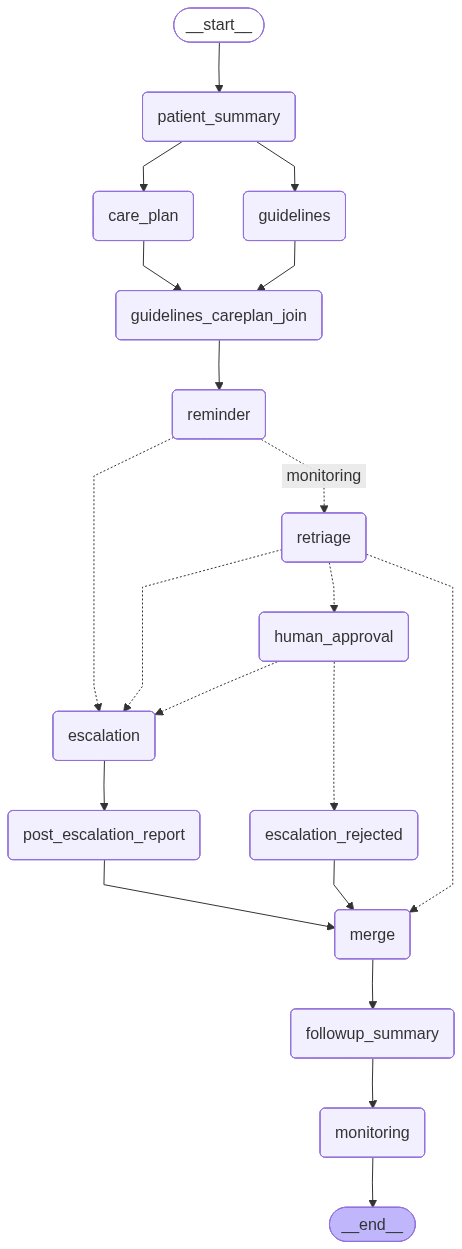

In [ ]:
graph

In [ ]:
print(graph.get_graph().draw_mermaid())

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	patient_summary(patient_summary)
	guidelines(guidelines)
	care_plan(care_plan)
	reminder(reminder)
	human_approval(human_approval)
	escalation(escalation)
	escalation_rejected(escalation_rejected)
	post_escalation_report(post_escalation_report)
	merge(merge)
	monitoring(monitoring)
	guidelines_careplan_join(guidelines_careplan_join)
	followup_summary(followup_summary)
	retriage(retriage)
	__end__([<p>__end__</p>]):::last
	__start__ --> patient_summary;
	care_plan --> guidelines_careplan_join;
	escalation --> post_escalation_report;
	escalation_rejected --> merge;
	followup_summary --> monitoring;
	guidelines --> guidelines_careplan_join;
	guidelines_careplan_join --> reminder;
	human_approval -.-> escalation;
	human_approval -.-> escalation_rejected;
	merge --> followup_summary;
	patient_summary --> care_plan;
	patient_summary --> guidelines;
	post_escalation_report --> merge;
	reminder -.-

In [ ]:
def make_initial_state(
    patient_id: str,
    patient_name: str,
    diagnosis: str,
    discharge_date: str,
    contact: str,
    risk_level: RiskLevel,
    follow_up_days: list[int] | None = None,
    preferences: dict | None = None,
) -> GraphState:
    return GraphState(
        conversation=ConversationState(messages=[]),
        patient_id=patient_id,
        patient_name=patient_name,
        diagnosis=diagnosis,
        discharge_date=discharge_date,
        contact=contact,
        risk_level=risk_level.value,
        original_risk_level=risk_level.value,
        follow_up_days=follow_up_days or [1, 3, 7],
        preferences=preferences or {
            "preferred_channel": "sms",
            "language": "en",
            "opted_out": False,
            "best_contact_time": "09:00-11:00",
        },
        summary=None,
        initial_summary=None,
        care_plan=None,
        patient_list=None,
        reminders_sent=[],
        escalation_task_id=None,
        escalation_required=False,
        human_approved=False,
        route="",
        errors=[],
        metrics_snapshot=None,
        discharge_guidelines=None,
        symptom_response=None,
        symptom_score_updated=None,
        last_contact_acknowledged=None,
        silence_hours=None,
        escalation_report=None
    )


In [ ]:
# resume_result = graph.invoke(
#     Command(
#         resume={
#             "escalation_level": "full",  # "full" | "partial" | "monitor" | "reject"
#             "reviewer": "Dr. Smith",
#             "comments": "Escalation approved — patient is high risk post-cardiac surgery"
#         }
#     ),
#     config={
#         "configurable": {
#             "thread_id": thread_id   # must match the thread_id used in Cell 13
#         }
#     }
# )

# print(resume_result)

In [ ]:
from IPython.display import display, HTML
import threading
import ipywidgets as widgets

C = {
    "bg":          "#ffffff",
    "bg2":         "#f8f9fc",
    "bg3":         "#f1f3f9",
    "text":        "#0f172a",
    "text2":       "#475569",
    "text3":       "#94a3b8",
    "accent":      "#6366f1",
    "accent_soft": "#eef2ff",
    "accent_mid":  "#818cf8",
    "border":      "#e2e8f0",
    "radius":      "10px",
    "radius_lg":   "16px",
    # semantic
    "high":        "#ef4444",
    "high_bg":     "#fef2f2",
    "high_br":     "#fecaca",
    "med":         "#f59e0b",
    "med_bg":      "#fffbeb",
    "med_br":      "#fde68a",
    "low":         "#10b981",
    "low_bg":      "#ecfdf5",
    "low_br":      "#a7f3d0",
}

def _style():
    return f"""
    <style>
        .qw * {{ box-sizing: border-box; font-family: -apple-system, 'Segoe UI', sans-serif; }}
        .qw {{
            background: {C['bg2']};
            border-radius: {C['radius_lg']};
            padding: 20px;
            margin: 8px 0;
            animation: slideIn 0.3s ease-out;
        }}
        .qw-card {{
            background: {C['bg']};
            border: 1px solid {C['border']};
            border-radius: {C['radius_lg']};
            padding: 16px 20px;
            margin: 10px 0;
            transition: all 0.2s ease;
        }}
        .qw-node {{
            background: {C['bg']};
            border: 1px solid {C['border']};
            border-left: 3px solid {C['accent_mid']};
            border-radius: 0 {C['radius']} {C['radius']} 0;
            margin: 6px 0 6px 8px;
            padding: 10px 14px;
            animation: slideInLeft 0.4s ease-out;
        }}
        .qw-label {{
            font-size: 11px;
            font-weight: 700;
            letter-spacing: 0.07em;
            text-transform: uppercase;
            color: {C['accent']};
            margin-bottom: 8px;
        }}
        .qw-row {{
            display: flex;
            gap: 12px;
            font-size: 13px;
            padding: 4px 0;
            border-bottom: 1px solid {C['border']};
            color: {C['text']};
        }}
        .qw-row:last-child {{ border-bottom: none; }}
        .qw-key {{
            color: {C['text3']};
            min-width: 150px;
            flex-shrink: 0;
            font-size: 12px;
        }}
        .qw-val {{ color: {C['text2']}; line-height: 1.6; font-size: 13px; }}
        .qw-err {{ color: {C['high']}; }}
        .qw-badge {{
            display: inline-block;
            font-size: 11px;
            font-weight: 700;
            padding: 3px 12px;
            border-radius: 20px;
            letter-spacing: 0.05em;
            transition: transform 0.2s ease;
        }}
        .qw-badge:hover {{
            transform: scale(1.05);
        }}
        .qw-mono {{
            font-family: 'SF Mono', 'Consolas', monospace;
            font-size: 11px;
            background: {C['bg3']};
            color: {C['accent']};
            padding: 2px 7px;
            border-radius: 5px;
            border: 1px solid {C['border']};
        }}
        .qw-divider {{
            border: none;
            border-top: 1px solid {C['border']};
            margin: 12px 0;
        }}
        .qw-avatar {{
            width: 40px; height: 40px;
            border-radius: 50%;
            background: {C['accent_soft']};
            border: 1px solid {C['accent_mid']}55;
            display: flex; align-items: center; justify-content: center;
            font-size: 14px; font-weight: 700;
            color: {C['accent']};
            flex-shrink: 0;
        }}

        /* Animation keyframes */
        @keyframes slideIn {{
            from {{
                opacity: 0;
                transform: translateY(-10px);
            }}
            to {{
                opacity: 1;
                transform: translateY(0);
            }}
        }}

        @keyframes slideInLeft {{
            from {{
                opacity: 0;
                transform: translateX(-20px);
            }}
            to {{
                opacity: 1;
                transform: translateX(0);
            }}
        }}

        @keyframes fadeIn {{
            from {{ opacity: 0; }}
            to {{ opacity: 1; }}
        }}

        @keyframes pulse {{
            0%, 100% {{ opacity: 1; }}
            50% {{ opacity: 0.5; }}
        }}

        @keyframes spin {{
            to {{ transform: rotate(360deg); }}
        }}

        @keyframes scaleIn {{
            from {{
                transform: scale(0) rotate(-180deg);
                opacity: 0;
            }}
            to {{
                transform: scale(1) rotate(0);
                opacity: 1;
            }}
        }}

        .qw-pulse {{
            animation: pulse 2s infinite;
        }}
    </style>
    """

NODE_ICONS = {
    "patient_summary":          "◈  Patient Summary",
    "guidelines":               "⊞  Guidelines",
    "care_plan":                "⊕  Care Plan",
    "reminder":                 "◎  Reminder",
    "escalation":               "⚑  Escalation",
    "escalation_rejected":      "⊗  Escalation Rejected",
    "post_escalation_report":   "⊡  Post-Escalation Report",
    "followup_summary":         "◉  Follow-up Summary",
    "monitoring":               "◈  Monitoring",
    "merge":                    "⊔  Merge",
    "human_approval":           "◐  Human Approval",
    "guidelines_careplan_join": "⊓  Join",
}

def display_patient_header(patient_name, patient_id, risk_level):
    risk = risk_level.lower()
    badge_map = {
        "high":   (C["high"],  C["high_bg"], C["high_br"]),
        "medium": (C["med"],   C["med_bg"],  C["med_br"]),
        "low":    (C["low"],   C["low_bg"],  C["low_br"]),
    }
    color, bg, border = badge_map.get(risk, (C["text3"], C["bg3"], C["border"]))
    initials = "".join(p[0].upper() for p in patient_name.split()[:2])

    display(HTML(f"""
    {_style()}
    <div class="qw">
        <div class="qw-card" style="margin:0;">
            <div style="display:flex; align-items:center; gap:14px;">
                <div class="qw-avatar">{initials}</div>
                <div style="flex:1;">
                    <div style="font-size:15px; font-weight:700; color:{C['text']};">{patient_name}</div>
                    <div style="margin-top:3px;">
                        <span class="qw-mono">{patient_id}</span>
                    </div>
                </div>
                <span class="qw-badge" style="color:{color}; background:{bg}; border:1px solid {border};">
                    {risk_level.upper()} RISK
                </span>
            </div>
        </div>
    </div>
    """))


def display_node_output(node_name, node_output):
    import re, json

    label = NODE_ICONS.get(node_name, f"·  {node_name.replace('_', ' ').title()}")
    rows_html = ""
    row_index = 0

    if isinstance(node_output, dict):
        for k, v in node_output.items():
            if not v or k in ("conversation", "metrics_snapshot", "initial_summary"):
                continue

            delay = row_index * 0.05

            if k == "summary":
                try:
                    parsed = json.loads(v) if isinstance(v, str) else v
                    pd_   = parsed.get("patient_details", {})
                    ci    = parsed.get("clinical_insights", {})
                    rec   = ci.get("follow_up_recommendation", {})

                    urgency_color = {"high": "#dc2626", "medium": "#d97706", "low": "#16a34a"}.get(
                        rec.get("urgency", "").lower(), "#6b7280"
                    )
                    risk_color = {"high": "#dc2626", "medium": "#d97706", "low": "#16a34a"}.get(
                        pd_.get("risk_level", "").lower(), "#6b7280"
                    )

                    insights_html = "".join(
                        f"<li style='margin-bottom:5px;padding-left:4px'>• {i}</li>"
                        for i in ci.get("quick_insights", [])
                    )

                    val = f"""
                        <div style='margin-bottom:10px; display:flex; flex-wrap:wrap; gap:8px; align-items:center;'>
                            <strong style='font-size:13px'>{pd_.get('patient_name','')}</strong>
                            <span style='color:#6b7280'>·</span>
                            <span>{pd_.get('diagnosis','')}</span>
                            <span style='color:#6b7280'>·</span>
                            <span>Discharged: {pd_.get('discharge_date','')}</span>
                            <span style='color:#6b7280'>·</span>
                            <span style='font-weight:600; color:{risk_color}'>
                                ⬤ {pd_.get('risk_level','').upper()} RISK
                            </span>
                        </div>
                        <ul style='margin:0 0 10px 0; padding:0; list-style:none; font-size:12px; color:#374151'>
                            {insights_html}
                        </ul>
                        <div style='font-size:12px; color:#4b5563; margin-bottom:10px; line-height:1.6'>
                            {ci.get('brief_explanation','')}
                        </div>
                        <div style='background:#eff6ff; border-left:3px solid {urgency_color};
                                    border-radius:6px; padding:8px 12px; font-size:12px;'>
                            <span style='font-weight:600; color:{urgency_color}'>
                                ▶ Next Step ({rec.get('urgency','').upper()}):
                            </span>
                            {rec.get('next_step','')}
                        </div>
                    """
                except Exception:
                    # fallback — raw string with basic formatting
                    val = str(v)
                    val = re.sub(r'\*\*(.+?)\*\*', r'<strong>\1</strong>', val)

                rows_html += f'''<div class="qw-row" style="animation:slideInLeft 0.4s ease-out {delay}s both;">
                    <span class="qw-key">{k}</span>
                    <span class="qw-val" style="white-space:normal; word-wrap:break-word;">{val}</span>
                </div>'''

            # ── Default rendering for all other keys ───────────────────────
            else:
                val = str(v)
                val = re.sub(r'\*\*(.+?)\*\*', r'<strong>\1</strong>', val)
                val = re.sub(r'(\d+\.)', r'<br>\1', val)
                val = re.sub(r'(\s-\s)', r'<br>-&nbsp;', val)

                if k == "errors" and v:
                    rows_html += f'<div class="qw-row" style="animation:slideInLeft 0.4s ease-out {delay}s both;"><span class="qw-key qw-err">⚠ {k}</span><span class="qw-val qw-err" style="white-space: pre-wrap; word-wrap: break-word;">{val}</span></div>'
                else:
                    rows_html += f'<div class="qw-row" style="animation:slideInLeft 0.4s ease-out {delay}s both;"><span class="qw-key">{k}</span><span class="qw-val" style="white-space: pre-wrap; word-wrap: break-word;">{val}</span></div>'

            row_index += 1

    if not rows_html:
        return

    display(HTML(f"""
    <div class="qw" style="padding:6px 20px;">
        <div class="qw-node">
            <div class="qw-label">{label}</div>
            {rows_html}
        </div>
    </div>
    """))

def display_resuming():
    display(HTML(f"""
    <div class="qw" style="padding:8px 20px;">
        <div style="display:flex; align-items:center; gap:8px;">
            <div style="
                width:16px; height:16px;
                border:2px solid {C['accent_soft']};
                border-top:2px solid {C['accent']};
                border-radius:50%;
                animation:spin 0.8s linear infinite;
            "></div>
            <span style="font-size:12px; color:{C['accent']}; font-weight:600; letter-spacing:0.05em;">
                Resuming workflow...
            </span>
        </div>
        <style>
            @keyframes spin {{
                to {{ transform: rotate(360deg); }}
            }}
        </style>
    </div>
    """))

def display_approval_input_colab(
    patient_name: str,
    patient_id: str,
    diagnosis: str,
    summary: str,
    symptom_response: str = None,       # ← NEW: passed from state
    symptom_score: int = None,          # ← NEW: passed from state
) -> str:
    """
    Shows the escalation approval prompt.
    Now includes the patient's own symptom response so the clinician
    can make an informed decision.
    """
    # Build symptom block only if we have a response
    if symptom_response and symptom_response != "NO_RESPONSE":
        score_label = (
            "Mild"   if (symptom_score or 0) <= 3 else
            "Moderate" if (symptom_score or 0) <= 6 else
            "Severe"
        )
        symptom_html = f"""
            <div class="qw-row">
                <span class="qw-key">Patient reported</span>
                <span class="qw-val" style="font-style:italic;">"{symptom_response[:200]}"</span>
            </div>
            <div class="qw-row">
                <span class="qw-key">Symptom score</span>
                <span class="qw-val">{symptom_score}/10 — {score_label}</span>
            </div>
        """
    elif symptom_response == "NO_RESPONSE":
        symptom_html = f"""
            <div class="qw-row">
                <span class="qw-key">Patient response</span>
                <span class="qw-val qw-err">⚠ No response received (48h silence)</span>
            </div>
        """
    else:
        symptom_html = ""

    display(HTML(f"""
    <div class="qw">
        <div class="qw-card" style="border-color:{C['high_br']}; background:{C['high_bg']}; margin:0; margin-bottom:16px;">
            <div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
                <span style="font-size:18px;">⚑</span>
                <span style="font-size:14px; font-weight:700; color:{C['high']};">Human Approval Required</span>
            </div>
            <hr class="qw-divider" style="border-color:{C['high_br']};">
            <div class="qw-row">
                <span class="qw-key">Patient</span>
                <span class="qw-val" style="color:{C['text']}; font-weight:600;">
                    {patient_name} &nbsp;<span class="qw-mono">{patient_id}</span>
                </span>
            </div>
            <div class="qw-row">
                <span class="qw-key">Diagnosis</span>
                <span class="qw-val" style="color:{C['text']};">{diagnosis}</span>
            </div>
            {symptom_html}
            <div class="qw-row">
                <span class="qw-key">Summary</span>
                <span class="qw-val" style="font-size:12px;">{str(summary)[:300]}…</span>
            </div>
            <hr class="qw-divider" style="border-color:{C['high_br']};">
            <div style="font-size:12px; color:{C['text2']}; line-height:2.2; display:flex; flex-wrap:wrap; gap:8px;">
                <span class="qw-mono">full</span> alert care team + physician + urgent task &nbsp;·&nbsp;
                <span class="qw-mono">reject</span> no action
            </div>
        </div>
    </div>
    """))

    while True:
        decision = input("→ Decision (full/reject): ").strip().lower()
        if decision in ("full", "reject"):
            display(HTML(f"""
            <div class="qw" style="padding:8px 20px;">
                <div style="
                    font-size:12px; font-weight:600; color:{C['low']};
                    background:{C['low_bg']}; border:1px solid {C['low_br']};
                    border-radius:{C['radius']}; padding:8px 12px;
                    display:flex; align-items:center; gap:6px;
                ">
                    <span>✓ Decision submitted: <strong>{decision.upper()}</strong></span>
                </div>
            </div>
            """))
            return decision
        else:
            display(HTML(f"""
            <div class="qw" style="padding:8px 20px;">
                <div style="
                    font-size:12px; font-weight:600; color:{C['high']};
                    background:{C['high_bg']}; border:1px solid {C['high_br']};
                    border-radius:{C['radius']}; padding:8px 12px;
                ">⚠ Invalid. Enter: full or reject</div>
            </div>
            """))



def display_done(patient_name, patient_id):
    display(HTML(f"""
    <div class="qw" style="padding:8px 20px;">
        <div style="
            font-size:13px; font-weight:600; color:{C['low']};
            background:{C['low_bg']};
            border:1px solid {C['low_br']};
            border-radius:{C['radius']};
            padding:10px 16px;
            display:flex; align-items:center; gap:8px;
            animation: slideIn 0.4s ease-out;
        ">
            <span style="
                display:inline-block;
                animation: scaleIn 0.5s cubic-bezier(0.34, 1.56, 0.64, 1);
            ">✓</span>
            <span>Completed — {patient_name}</span>
            <span class="qw-mono" style="margin-left:4px;">{patient_id}</span>
        </div>
        <style>
            @keyframes scaleIn {{
                from {{
                    transform: scale(0) rotate(-180deg);
                    opacity: 0;
                }}
                to {{
                    transform: scale(1) rotate(0);
                    opacity: 1;
                }}
            }}
        </style>
    </div>
    """))

def run_all_patients() -> list[dict]:
    patients_res = supabase.table("patients").select("*").execute()
    ehr_res = supabase.table("ehr_records").select("*").execute()

    if not patients_res.data:
        logger.warn("run_all_patients", "No patients found in DB")
        return []

    ehr_lookup = {r["patient_id"]: r for r in ehr_res.data}
    results = []

    for row in patients_res.data:
        patient_id = str(row["patient_id"])
        ehr = ehr_lookup.get(patient_id)

        if not ehr:
            logger.warn("run_all_patients", f"No EHR record for {patient_id} — skipping")
            continue

        try:
            tid = f"thread_{patient_id}_{datetime.now().strftime('%Y%m%d%H%M%S')}"
            config = {"configurable": {"thread_id": tid}}
            state = make_initial_state(
                patient_id=patient_id,
                patient_name=str(row["patient_name"]),
                diagnosis=str(ehr["diagnosis"]),
                discharge_date=str(ehr["discharge_date"]),
                contact=str(row["contact"]),
                risk_level=RiskLevel(str(ehr["risk_level"]).lower()),
                follow_up_days=ehr.get("follow_up_days") or [1, 3, 7],
            )

            display_patient_header(row["patient_name"], patient_id, ehr["risk_level"])

            result = {}
            for chunk in graph.stream(state, config=config, stream_mode="updates"):
                for node_name, node_output in chunk.items():
                    display_node_output(node_name, node_output)
                    if isinstance(node_output, dict):
                        result.update(node_output)

            if result.get("escalation_required"):
                decision = display_approval_input_colab(
                    patient_name=row["patient_name"],
                    patient_id=patient_id,
                    diagnosis=ehr["diagnosis"],
                    summary=result.get("initial_summary") or result.get("summary", "N/A"),
                    symptom_response=result.get("symptom_response"),   # ← NEW
                    symptom_score=result.get("symptom_score_updated"), # ← NEW
                )

                for chunk in graph.stream(
                    Command(resume={"escalation_level": decision}),
                    config=config,
                    stream_mode="updates",
                ):
                    for node_name, node_output in chunk.items():
                        display_node_output(node_name, node_output)
                        if isinstance(node_output, dict):
                            result.update(node_output)

            result["_thread_id"] = tid
            results.append(result)
            display_done(row["patient_name"], patient_id)

        except Exception as exc:
            logger.error("run_all_patients", f"Failed for patient {patient_id}: {exc}")
            metrics.increment("errors_caught")
            continue

    logger.info("run_all_patients", f"Completed {len(results)}/{len(patients_res.data)} patients")
    return results

In [ ]:
results = run_all_patients()

ERROR:PatientFollowUp:[tool_send_sms] ERROR: HTTP 429 error: Unable to create record: Account ACe60bab94d64fa64264d3864fe8f60a1c exceeded the 50 daily messages limit | {}


ERROR:PatientFollowUp:[send_sms] ERROR: HTTP 429 error: Unable to create record: Account ACe60bab94d64fa64264d3864fe8f60a1c exceeded the 50 daily messages limit | {}


→ Meera: i am having severe chest pain


ERROR:PatientFollowUp:[retriage_node] ERROR: Closing SMS failed: HTTP 429 error: Unable to create record: Account ACe60bab94d64fa64264d3864fe8f60a1c exceeded the 50 daily messages limit | {}


→ Decision (full/reject): full


...

→ Rajesh: i am feeling better


ERROR:PatientFollowUp:[retriage_node] ERROR: Closing SMS failed: HTTP 429 error: Unable to create record: Account ACe60bab94d64fa64264d3864fe8f60a1c exceeded the 50 daily messages limit | {}


ERROR:PatientFollowUp:[tool_send_sms] ERROR: HTTP 429 error: Unable to create record: Account ACe60bab94d64fa64264d3864fe8f60a1c exceeded the 50 daily messages limit | {}


ERROR:PatientFollowUp:[send_sms] ERROR: HTTP 429 error: Unable to create record: Account ACe60bab94d64fa64264d3864fe8f60a1c exceeded the 50 daily messages limit | {}


KeyboardInterrupt: Interrupted by user